In [ ]:
# Load the dataset
import pandas as pd

bike_rental = pd.read_csv("Dataset.csv")
bike_rental.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


The dataset contains 17379 rows and 17 columns\.

The column cnt is our target which is continuous variable, therefore this is a regression problem.

Since target column is known , this falls under the concept of supervised learning.

In [ ]:
# Check dataset size
bike_rental.shape

(17379, 17)

In [ ]:
# show information of dataset
bike_rental.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   instant     17379 non-null  int64 
 1   dteday      17379 non-null  object
 2   season      17379 non-null  object
 3   yr          17379 non-null  object
 4   mnth        17379 non-null  object
 5   hr          17379 non-null  int64 
 6   holiday     17379 non-null  object
 7   weekday     17379 non-null  int64 
 8   workingday  17379 non-null  object
 9   weathersit  17379 non-null  object
 10  temp        17379 non-null  object
 11  atemp       17379 non-null  object
 12  hum         17379 non-null  object
 13  windspeed   17379 non-null  object
 14  casual      17379 non-null  object
 15  registered  17379 non-null  object
 16  cnt         17379 non-null  int64 
dtypes: int64(4), object(13)
memory usage: 2.3+ MB


It's indicating that there is no missing values.

Although no null values are reported , some columns may contain special characters such as #,? should be checked separately.

It contains both numerical and categorical features.

In [ ]:
# show statistical summary
bike_rental.describe()

,instant,hr,weekday,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000
mean,8690.0000,11.546752,3.003683,189.463088
std,5017.0295,6.914405,2.005771,181.387599
min,1.0000,0.000000,0.000000,1.000000
25%,4345.5000,6.000000,1.000000,40.000000
50%,8690.0000,12.000000,3.000000,142.000000
75%,13034.5000,18.000000,5.000000,281.000000
max,17379.0000,23.000000,6.000000,977.000000


In [ ]:
# Check duplicate records
bike_rental.duplicated().sum()

np.int64(0)

In [ ]:
# Check missing values
bike_rental.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [ ]:
# Check for '?' values
(bike_rental.isin(['?', '#', 'N/A', 'NA', 'null', 'None', '-', ''])).sum()

,0
instant,0
dteday,0
season,6
yr,1
mnth,1
hr,0
holiday,1
weekday,0
workingday,5
weathersit,4


In [ ]:
# Replace '?' with NaN
import numpy as np
bike_rental.replace(['?', '#', 'N/A', 'NA', 'null', 'None', '-', ''], np.nan, inplace=True)

In [ ]:
# Drop irrelevent columns
bike_rental.drop(columns=['instant'], inplace=True)

In [ ]:
# Check data types
bike_rental.dtypes

,0
dteday,object
season,object
yr,object
mnth,object
hr,int64
holiday,object
weekday,int64
workingday,object
weathersit,object
temp,object


In [ ]:
# Fix data types
num_cols = ['temp', 'atemp', 'hum', 'windspeed', 'yr', 'mnth', 'casual', 'registered']
for col in num_cols:
    bike_rental[col] = pd.to_numeric(bike_rental[col], errors='coerce')

bike_rental.dtypes

,0
dteday,object
season,object
yr,float64
mnth,float64
hr,int64
holiday,object
weekday,int64
workingday,object
weathersit,object
temp,float64


In [ ]:
# Categorical columns — fill with mode
cat_cols = ['season', 'holiday', 'workingday', 'weathersit']
for col in cat_cols:
    bike_rental[col] = bike_rental[col].fillna(bike_rental[col].mode()[0])

In [ ]:
# Numeric columns — fill with median
num_only = bike_rental.select_dtypes(include='number').columns
bike_rental[num_only] = bike_rental[num_only].fillna(bike_rental[num_only].median())

In [ ]:
# Verify no missing values remain
bike_rental.isnull().sum()

,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

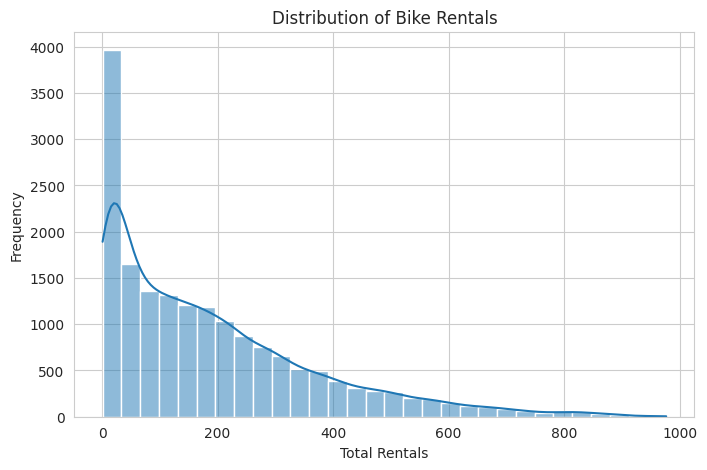

In [ ]:
# Distribuation of bike rentals
plt.figure(figsize=(8,5))

sns.histplot(
    bike_rental['cnt'],
    bins=30,
    kde=True
)

plt.title('Distribution of Bike Rentals')
plt.xlabel('Total Rentals')
plt.ylabel('Frequency')

plt.show()

 Observation:

 Bike rental counts are right-skewed, with most rentals occurring at lower values.

 A few peak-demand periods show significantly higher rental counts.

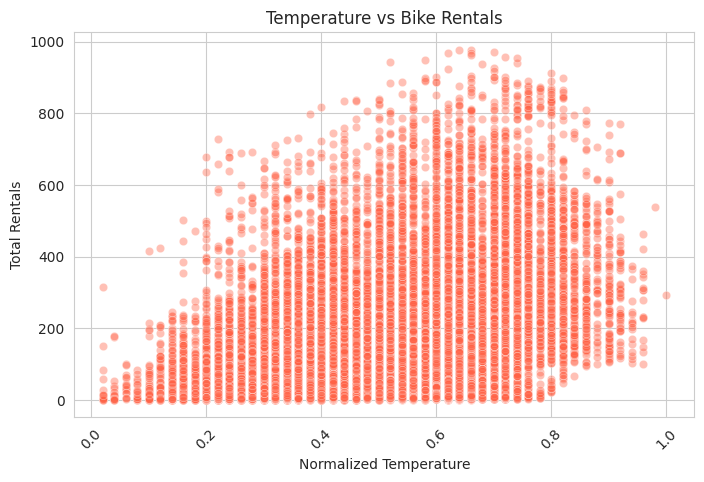

In [ ]:
# Temperature vs bike renatls

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='temp',
    y='cnt',
    data=bike_rental,
    alpha=0.4,
    color='tomato'
)

plt.title('Temperature vs Bike Rentals')
plt.xticks(rotation=45)
plt.xlabel('Normalized Temperature')
plt.ylabel('Total Rentals')

plt.show()

Observation:

Temperature has a positive impact on bike rental demand.

The highest rental counts are observed at moderate to warm temperatures, while lower temperatures show reduced demand.

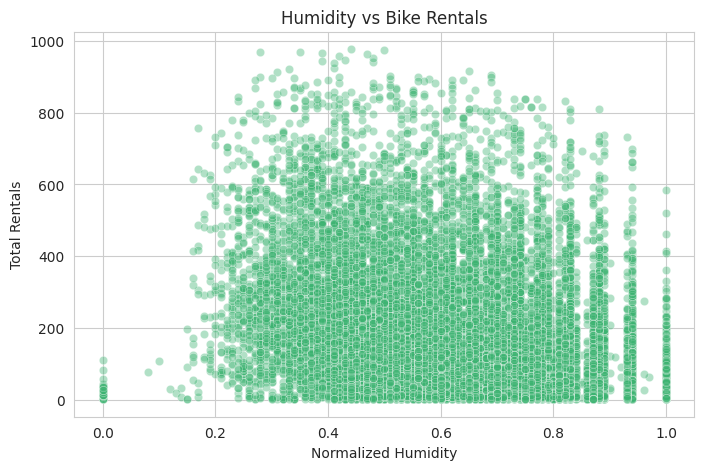

In [ ]:
# humidity vs bike rentals

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='hum',
    y='cnt',
    data=bike_rental,
    alpha=0.4,
    color='mediumseagreen'
)

plt.title('Humidity vs Bike Rentals')
plt.xlabel('Normalized Humidity')
plt.ylabel('Total Rentals')

plt.show()

Observation:

 Most bike rentals occur at moderate humidity levels.

 Higher humidity generally corresponds to slightly lower rental demand.

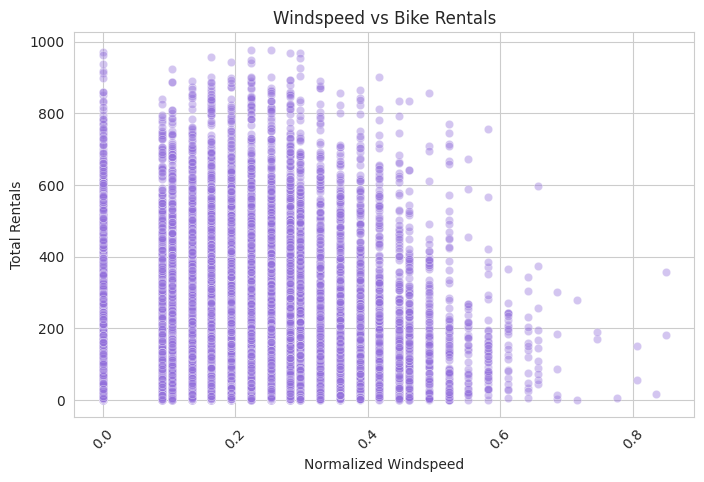

In [ ]:
# windspeed vs bike rentals

plt.figure(figsize=(8,5))

sns.scatterplot(
    x='windspeed',
    y='cnt',
    data=bike_rental,
    alpha=0.4,
    color='mediumpurple'
)
plt.xticks(rotation=45)
plt.title('Windspeed vs Bike Rentals')
plt.xlabel('Normalized Windspeed')
plt.ylabel('Total Rentals')

plt.show()

 Observation:

Most bike rentals occur when windspeed is low to moderate.

High windspeed conditions are associated with lower rental demand, indicating a negative relationship.

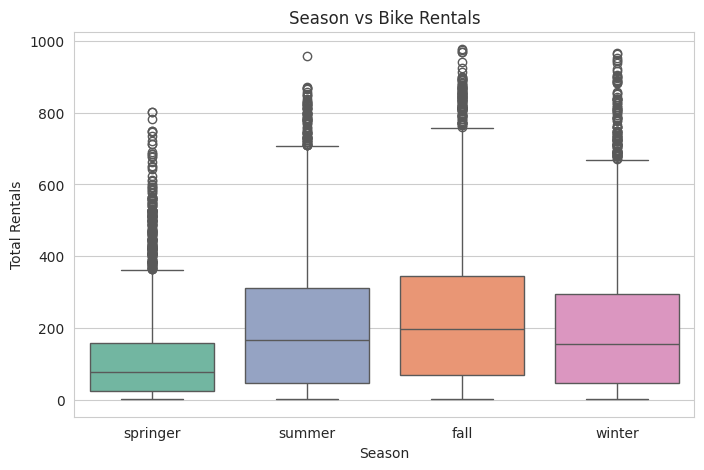

In [ ]:
# season vs bike rentals
plt.figure(figsize=(8,5))

sns.boxplot(
    x='season',
    y='cnt',
    data=bike_rental,
    order=['springer', 'summer', 'fall', 'winter'],
    hue='season',
    palette='Set2',
    legend=False
)

plt.title('Season vs Bike Rentals')
plt.xlabel('Season')
plt.ylabel('Total Rentals')

plt.show()

Observation:

Bike rentals are generally higher in Fall and lower in Spring.

The presence of many outliers indicates occasional days with exceptionally high rental demand.

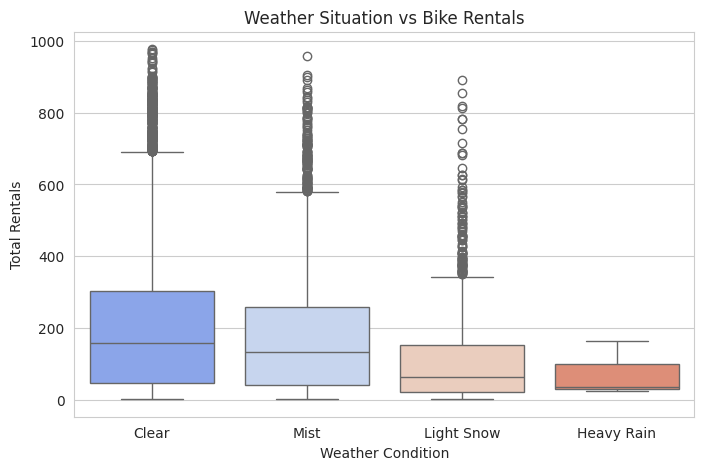

In [ ]:
# weather situation vs bike rentals
plt.figure(figsize=(8,5))

sns.boxplot(
    x='weathersit',
    y='cnt',
    data=bike_rental,
    order=['Clear', 'Mist', 'Light Snow', 'Heavy Rain'],
    hue='weathersit',
    palette='coolwarm',
    legend=False
)

plt.title('Weather Situation vs Bike Rentals')
plt.xlabel('Weather Condition')
plt.ylabel('Total Rentals')

plt.show()

Observation:


Bike rentals are highest during Clear weather and gradually decrease as weather conditions worsen.

Heavy Rain shows the lowest rental demand, indicating that unfavorable weather reduces bike usage.

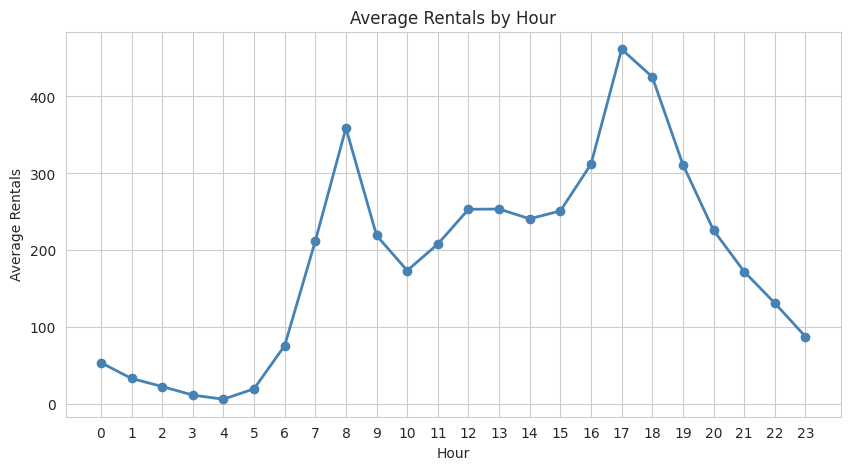

In [ ]:
# average rentals by hour
hourly = bike_rental.groupby('hr')['cnt'].mean()

plt.figure(figsize=(10,5))

hourly.plot(
    marker='o',
    color='steelblue',
    linewidth=2
)

plt.title('Average Rentals by Hour')
plt.xlabel('Hour')
plt.ylabel('Average Rentals')

plt.xticks(range(24))
plt.show()

Observation:

Bike rentals show two peak periods, around 8 AM and 5–6 PM.

 Rental demand is lowest during late night and early morning hours.

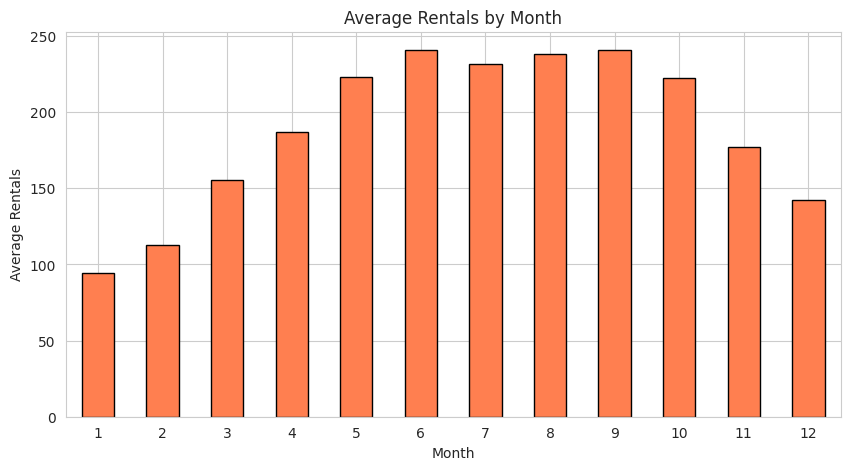

In [ ]:
# Average rentals by month

monthly = bike_rental.groupby('mnth')['cnt'].mean().sort_index()

plt.figure(figsize=(10, 5))
monthly.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Average Rentals by Month')
plt.xlabel('Month')
plt.ylabel('Average Rentals')
plt.xticks(ticks=range(12), labels=range(1, 13), rotation=0)

plt.show()

Observarion:

Average bike rentals gradually increase from January and reach their highest levels during June to September.

Rentals decline during November, December, and January, indicating lower demand in colder months.

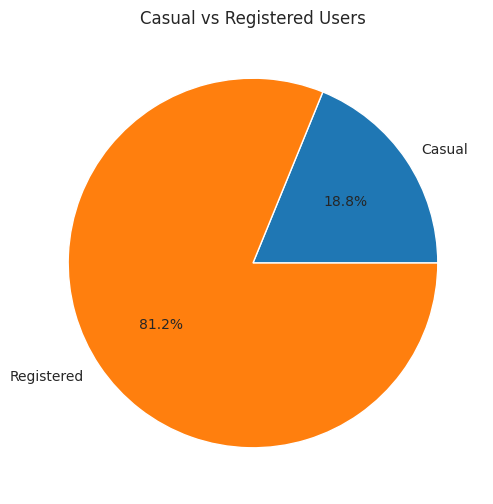

In [ ]:
# Casual vs registered users

user_counts = [bike_rental['casual'].sum(), bike_rental['registered'].sum()]
labels = ['Casual', 'Registered']

plt.figure(figsize=(6, 6))
plt.pie(user_counts,
        labels=labels,
        autopct='%1.1f%%'
        )
plt.title('Casual vs Registered Users')

plt.show()

Obseravtion:

Registered users contribute 81.2% of total bike rentals, while casual users account for only 18.8%.

This indicates that the bike rental system is primarily used by regular and subscribed customers.

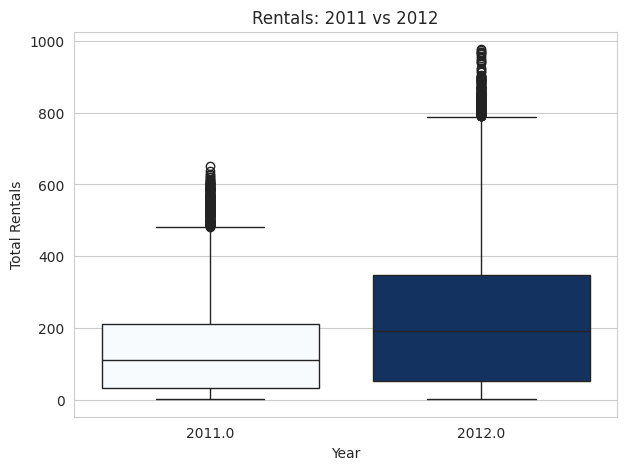

In [ ]:
# Year wise comparison
plt.figure(figsize=(7, 5))
sns.boxplot(x='yr', y='cnt', data=bike_rental,
            hue='yr', palette='Blues', legend=False)
plt.title('Rentals: 2011 vs 2012')
plt.xlabel('Year')
plt.ylabel('Total Rentals')
plt.show()

Observation:

2012 shows higher rentals than 2011 — both median and upper quartile are higher.

Business grew year-on-year, indicating increasing adoption of bike rentals.

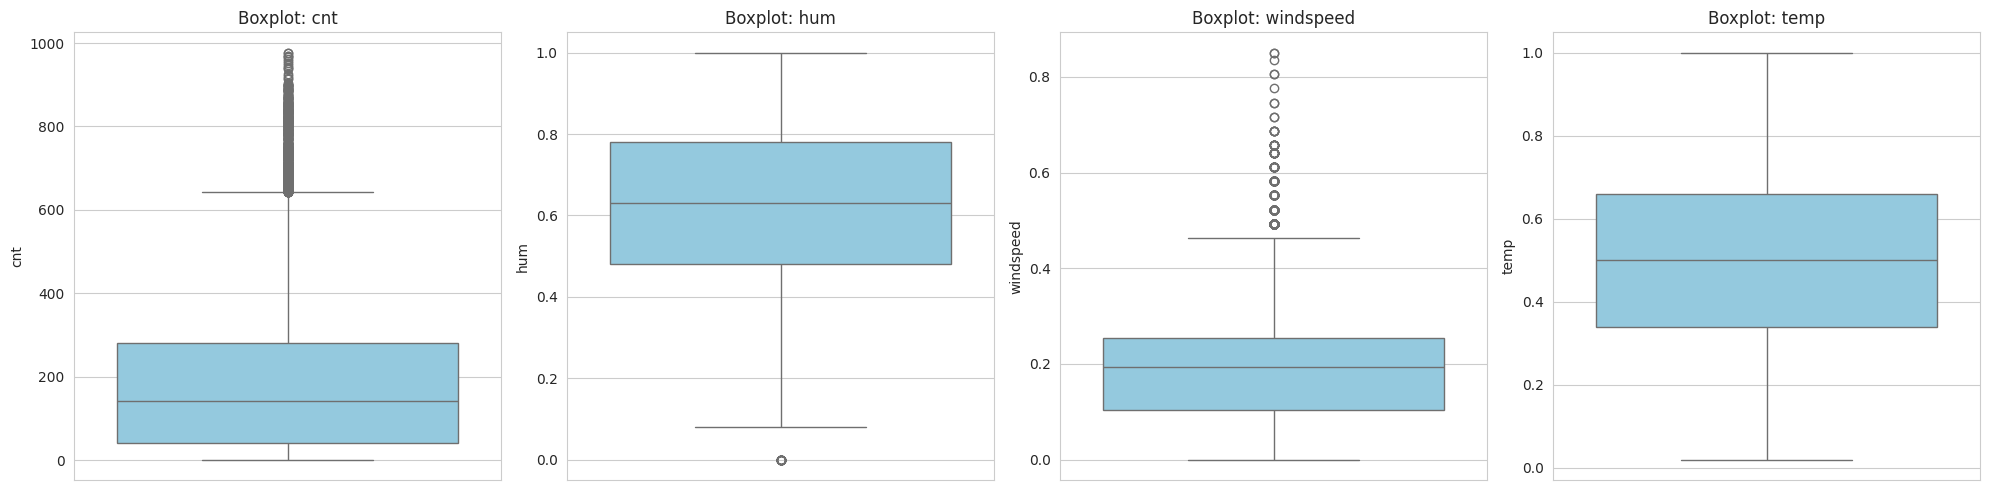

In [ ]:
# Outlier detection
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, col in zip(axes, ['cnt', 'hum', 'windspeed', 'temp']):
    sns.boxplot(y=bike_rental[col], ax=ax, color='skyblue')
    ax.set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

In [ ]:
# IQR based outlier count
for col in ['cnt', 'hum', 'windspeed', 'temp']:
    Q1 = bike_rental[col].quantile(0.25)
    Q3 = bike_rental[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((bike_rental[col] < lower) | (bike_rental[col] > upper)).sum()
    print(f"{col}: {n_out} outliers")

cnt: 505 outliers
hum: 22 outliers
windspeed: 341 outliers
temp: 0 outliers


In [ ]:
# Outlier treatment

# Fix hum == 0 (0% humidity is physically impossible — sensor error)

hum_median = bike_rental['hum'].median()
bike_rental['hum'] = bike_rental['hum'].replace(0, hum_median)
print(f"hum==0 rows after treatment: {(bike_rental['hum'] == 0).sum()}")

hum==0 rows after treatment: 0


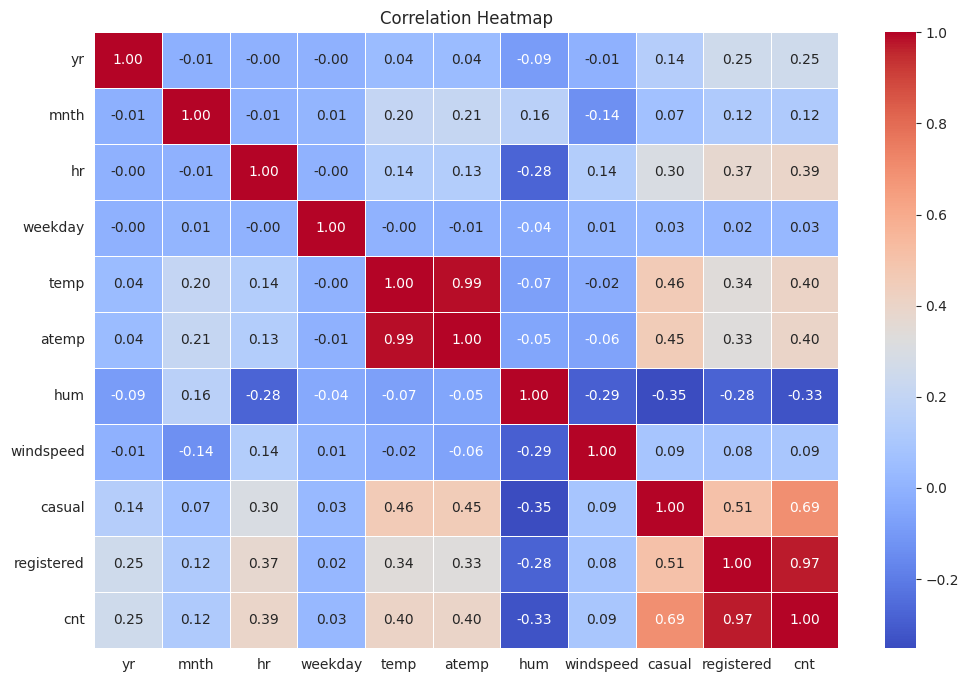

In [ ]:
# Correlation heatmap

plt.figure(figsize=(12, 8))
corr = bike_rental.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5)

plt.title('Correlation Heatmap')
plt.show()

 observation:

 Registered users have the strongest positive correlation, indicating that they are the primary contributors to overall rental demand.

 Casual users also show a positive correlation, but their impact is lower compared to registered users.

 Humidity has a moderate negative correlation, suggesting that higher humidity tends to reduce rental activity.

 The hour of the day shows a positive correlation, indicating that rental demand varies significantly across different times of the day.

 Windspeed and weekday exhibit very weak correlations with total rentals, implying that they have little influence on bike rental demand.


In [ ]:
# Drop unnecessary columns

# casual + registered = cnt exactly
# Drop atemp — multicollinearity with temp (r=0.99)

bike_rental.drop(columns=['casual', 'registered', 'atemp'], inplace=True)
print("Shape after dropping columns:", bike_rental.shape)

Shape after dropping columns: (17379, 13)


In [ ]:
# Convert dteday string to datetime — format is DD-MM-YYYY
bike_rental['dteday'] = pd.to_datetime(bike_rental['dteday'], dayfirst=True)

In [ ]:
# Extract useful features
bike_rental['is_weekend'] = bike_rental['dteday'].dt.dayofweek.isin([5, 6]).astype(int)
bike_rental['quarter']    = bike_rental['dteday'].dt.quarter

In [ ]:
# Drop raw date — cannot be fed to a model directly
bike_rental.drop(columns=['dteday'], inplace=True)

In [ ]:
print(bike_rental[['is_weekend', 'quarter']].head())

   is_weekend  quarter
0           1        1
1           1        1
2           1        1
3           1        1
4           1        1


In [ ]:
# giving model explicit signal about high and low demand months
bike_rental['is_summer'] = bike_rental['mnth'].apply(lambda x: 1 if x in [5,6,7,8]   else 0)
bike_rental['is_winter'] = bike_rental['mnth'].apply(lambda x: 1 if x in [11,12,1,2] else 0)

print(bike_rental[['mnth','is_summer','is_winter']].drop_duplicates().sort_values('mnth'))

      mnth  is_summer  is_winter
0      1.0          0          1
688    2.0          0          1
1337   3.0          0          0
2067   4.0          0          0
2786   5.0          1          0
3530   6.0          1          0
4250   7.0          1          0
4994   8.0          1          0
5725   9.0          0          0
6442  10.0          0          0
7185  11.0          0          1
7904  12.0          0          1


In [ ]:
# One-Hot Encoding

# converting categorical text columns into numbers for the model
categorical_cols = ['season', 'holiday', 'workingday', 'weathersit']

bike_rental = pd.get_dummies(bike_rental, columns=categorical_cols, drop_first=True,dtype=int)

print("Shape after encoding:", bike_rental.shape)
bike_rental.head()

Shape after encoding: (17379, 20)


,yr,mnth,hr,weekday,temp,hum,windspeed,cnt,is_weekend,quarter,is_summer,is_winter,season_springer,season_summer,season_winter,holiday_Yes,workingday_Working Day,weathersit_Heavy Rain,weathersit_Light Snow,weathersit_Mist
0,2011.0,1.0,0,6,0.24,0.81,0.0,16,1,1,0,1,1,0,0,0,0,0,0,0
1,2011.0,1.0,1,6,0.22,0.80,0.0,40,1,1,0,1,1,0,0,0,0,0,0,0
2,2011.0,1.0,2,6,0.22,0.63,0.0,32,1,1,0,1,1,0,0,0,0,0,0,0
3,2011.0,1.0,3,6,0.24,0.75,0.0,13,1,1,0,1,1,0,0,0,0,0,0,0
4,2011.0,1.0,4,6,0.24,0.75,0.0,1,1,1,0,1,1,0,0,0,0,0,0,0


In [ ]:
# Standard Scaling

# bringing all numeric weather columns to same scale
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scale_cols = ['temp','hum', 'windspeed']
bike_rental[scale_cols] = scaler.fit_transform(bike_rental[scale_cols])

print(bike_rental[scale_cols].describe().round(2))

           temp       hum  windspeed
count  17379.00  17379.00   17379.00
mean       0.00     -0.00       0.00
std        1.00      1.00       1.00
min       -2.48     -2.86      -1.55
25%       -0.82     -0.77      -0.70
50%        0.01      0.01       0.03
75%        0.85      0.79       0.52
max        2.61      1.94       5.40


In [ ]:
print("Final dataset shape:", bike_rental.shape)
bike_rental.head()

Final dataset shape: (17379, 20)


,yr,mnth,hr,weekday,temp,hum,windspeed,cnt,is_weekend,quarter,is_summer,is_winter,season_springer,season_summer,season_winter,holiday_Yes,workingday_Working Day,weathersit_Heavy Rain,weathersit_Light Snow,weathersit_Mist
0,2011.0,1.0,0,6,-1.336047,0.949847,-1.554228,16,1,1,0,1,1,0,0,0,0,0,0,0
1,2011.0,1.0,1,6,-1.439966,0.897656,-1.554228,40,1,1,0,1,1,0,0,0,0,0,0,0
2,2011.0,1.0,2,6,-1.439966,0.010406,-1.554228,32,1,1,0,1,1,0,0,0,0,0,0,0
3,2011.0,1.0,3,6,-1.336047,0.636700,-1.554228,13,1,1,0,1,1,0,0,0,0,0,0,0
4,2011.0,1.0,4,6,-1.336047,0.636700,-1.554228,1,1,1,0,1,1,0,0,0,0,0,0,0


In [ ]:
# Model building

In [ ]:
# Split dataset into train and test sets

from sklearn.model_selection import train_test_split

X = bike_rental.drop('cnt', axis=1)
y = bike_rental['cnt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (13903, 19)
X_test: (3476, 19)


In [ ]:
# Train base models

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

lr  = LinearRegression()
knn = KNeighborsRegressor()
dt  = DecisionTreeRegressor(random_state=42)
rf  = RandomForestRegressor(random_state=42)
gb  = GradientBoostingRegressor(random_state=42)
xgb = XGBRegressor(random_state=42, verbosity=0)

models = [lr, knn, dt, rf, gb, xgb]
for m in models:
    m.fit(X_train, y_train)
    print(f"{m.__class__.__name__} trained")

LinearRegression trained
KNeighborsRegressor trained
DecisionTreeRegressor trained
RandomForestRegressor trained
GradientBoostingRegressor trained
XGBRegressor trained


In [ ]:
# Evaluate base models (RMSE, MAE, R-squared)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(model):
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    return mae, mse, rmse, r2

base_models = {
    'Linear Regression': lr,
    'KNN': knn,
    'Decision Tree': dt,
    'Random Forest': rf,
    'Gradient Boosting': gb,
    'XGBoost': xgb
}

for name, model in base_models.items():
    mae, mse, rmse, r2 = evaluate(model)
    print(f"{name:<20} → MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")

Linear Regression    → MAE: 103.29, MSE: 18857.96, RMSE: 137.32, R²: 0.404
KNN                  → MAE: 37.89, MSE: 3442.49, RMSE: 58.67, R²: 0.891
Decision Tree        → MAE: 35.99, MSE: 3854.69, RMSE: 62.09, R²: 0.878
Random Forest        → MAE: 24.88, MSE: 1800.03, RMSE: 42.43, R²: 0.943
Gradient Boosting    → MAE: 45.46, MSE: 4399.14, RMSE: 66.33, R²: 0.861
XGBoost              → MAE: 25.25, MSE: 1657.85, RMSE: 40.72, R²: 0.948


In [ ]:
# Hyperparameter tuning — KNN

from sklearn.model_selection import GridSearchCV

knn_params = {'n_neighbors': [5, 10, 15, 20]}

knn_grid = GridSearchCV(KNeighborsRegressor(), knn_params, cv=5, scoring='r2', n_jobs=-1)
knn_grid.fit(X_train, y_train)

print("Best Params:", knn_grid.best_params_)
print("Best CV R² :", round(knn_grid.best_score_, 3))

Best Params: {'n_neighbors': 5}
Best CV R² : 0.878


In [ ]:
# Hyperparameter tuning — Decision Tree

dt_params = {
    'max_depth'        : [5, 10, 15, None],
    'min_samples_split': [2, 5, 10]
}

dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=42),
                       dt_params, cv=5, scoring='r2', n_jobs=-1)
dt_grid.fit(X_train, y_train)

print("Best Params:", dt_grid.best_params_)
print("Best CV R² :", round(dt_grid.best_score_, 3))

Best Params: {'max_depth': 15, 'min_samples_split': 10}
Best CV R² : 0.902


In [ ]:
# Hyperparameter tuning — Random Forest

rf_params = {
    'n_estimators': [50, 100],
    'max_depth'   : [10, 15, 20, None]
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state=42),
                       rf_params, cv=5, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("Best Params:", rf_grid.best_params_)
print("Best CV R² :", round(rf_grid.best_score_, 3))

Best Params: {'max_depth': 20, 'n_estimators': 100}
Best CV R² : 0.94


In [ ]:
# Hyperparameter tuning — Gradient Boosting

gb_params = {
    'n_estimators' : [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth'    : [3, 5]
}

gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42),
                       gb_params, cv=5, scoring='r2', n_jobs=-1)
gb_grid.fit(X_train, y_train)

print("Best Params:", gb_grid.best_params_)
print("Best CV R² :", round(gb_grid.best_score_, 3))

Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Best CV R² : 0.933


In [ ]:
# Hyperparameter tuning — XGBoost

xgb_params = {
    'n_estimators' : [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth'    : [4, 6]
}

xgb_grid = GridSearchCV(XGBRegressor(random_state=42, verbosity=0),
                        xgb_params, cv=5, scoring='r2', n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print("Best Params:", xgb_grid.best_params_)
print("Best CV R² :", round(xgb_grid.best_score_, 3))

Best Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Best CV R² : 0.947


In [ ]:
# Evaluate tuned models (Linear Regression has no hyperparams tuned — kept as baseline)

tuned_models = {
    'Linear Regression': lr,
    'KNN'               : knn_grid,
    'Decision Tree'      : dt_grid,
    'Random Forest'      : rf_grid,
    'Gradient Boosting'  : gb_grid,
    'XGBoost'            : xgb_grid
}

for name, model in tuned_models.items():
    mae, mse, rmse, r2 = evaluate(model)
    print(f"{name:<20} → MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.3f}")

Linear Regression    → MAE: 103.29, MSE: 18857.96, RMSE: 137.32, R²: 0.404
KNN                  → MAE: 37.89, MSE: 3442.49, RMSE: 58.67, R²: 0.891
Decision Tree        → MAE: 31.85, MSE: 3078.32, RMSE: 55.48, R²: 0.903
Random Forest        → MAE: 24.76, MSE: 1768.63, RMSE: 42.06, R²: 0.944
Gradient Boosting    → MAE: 28.51, MSE: 1996.09, RMSE: 44.68, R²: 0.937
XGBoost              → MAE: 24.51, MSE: 1596.92, RMSE: 39.96, R²: 0.950


In [ ]:
# Cross validation on best model — XGBoost

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(xgb_grid.best_estimator_, X, y, cv=5, scoring='r2')

print("CV R² scores:", cv_scores.round(3))
print("Mean R²:", round(cv_scores.mean(), 3))
print("Std:", round(cv_scores.std(), 3))

CV R² scores: [0.622 0.902 0.864 0.922 0.902]
Mean R²: 0.842
Std: 0.112


In [ ]:
# Final comparison — all 6 models, base vs tuned

import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'KNN', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'Base R²' : [0.404, 0.891, 0.878, 0.943, 0.861, 0.948],
    'Tuned R²': [0.404, 0.891, 0.903, 0.944, 0.937, 0.950],
    'Tuned MAE' : [103.29, 37.89, 31.85, 24.76, 28.51, 24.51],
    'Tuned RMSE': [137.32, 58.67, 55.48, 42.06, 44.68, 39.96]
})

comparison = comparison.sort_values('Tuned R²', ascending=False).reset_index(drop=True)
print(comparison.to_string(index=False))

            Model  Base R²  Tuned R²  Tuned MAE  Tuned RMSE
          XGBoost    0.948     0.950      24.51       39.96
    Random Forest    0.943     0.944      24.76       42.06
Gradient Boosting    0.861     0.937      28.51       44.68
    Decision Tree    0.878     0.903      31.85       55.48
              KNN    0.891     0.891      37.89       58.67
Linear Regression    0.404     0.404     103.29      137.32


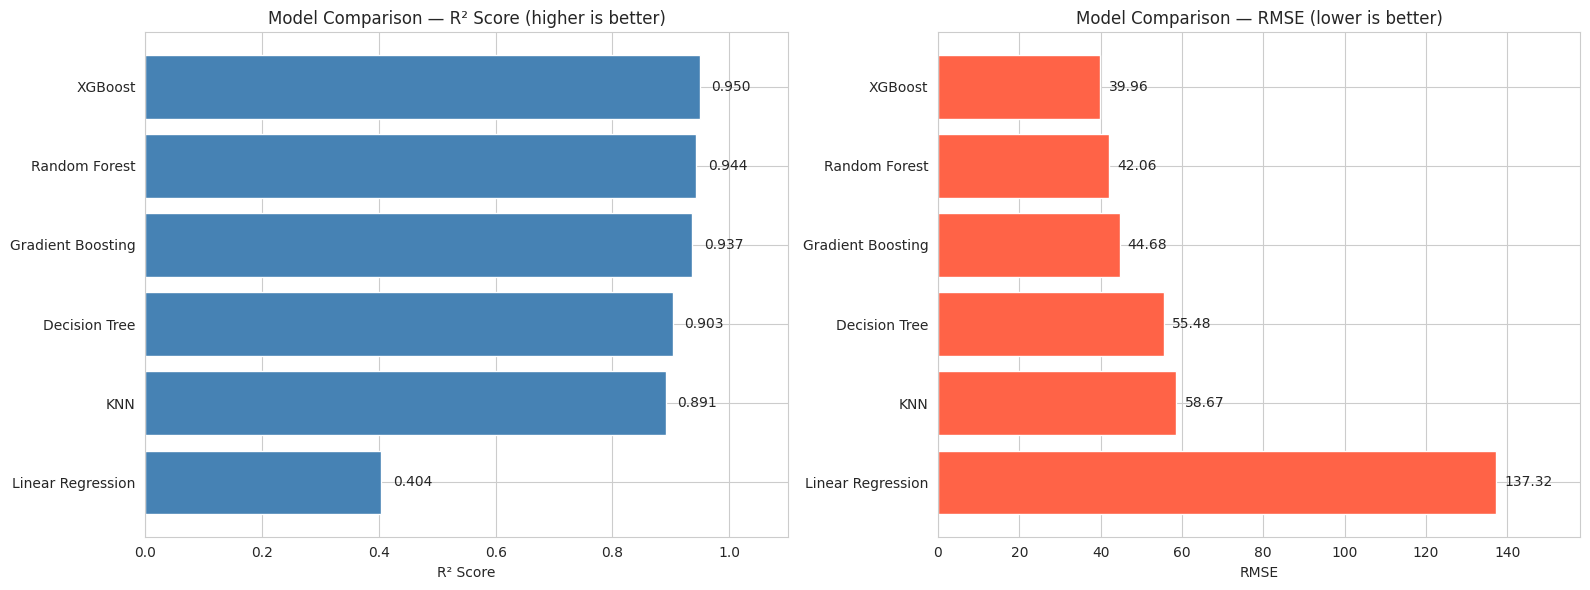

In [ ]:
# Visualization — model comparison

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² comparison

axes[0].barh(comparison['Model'], comparison['Tuned R²'], color='steelblue')
axes[0].set_xlabel('R² Score')
axes[0].set_title('Model Comparison — R² Score (higher is better)')
axes[0].invert_yaxis()
axes[0].set_xlim(0, 1.1)
for i, v in enumerate(comparison['Tuned R²']):
    axes[0].text(v + 0.02, i, f"{v:.3f}", va='center')

# RMSE comparison

axes[1].barh(comparison['Model'], comparison['Tuned RMSE'], color='tomato')
axes[1].set_xlabel('RMSE')
axes[1].set_title('Model Comparison — RMSE (lower is better)')
axes[1].invert_yaxis()
axes[1].set_xlim(0, comparison['Tuned RMSE'].max() * 1.15)
for i, v in enumerate(comparison['Tuned RMSE']):
    axes[1].text(v + 2, i, f"{v:.2f}", va='center')

plt.tight_layout()
plt.show()

In [ ]:
# Best model — XGBoost

best_model = xgb_grid.best_estimator_

mae, mse, rmse, r2 = evaluate(best_model)

print("FINAL BEST MODEL: XGBoost")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.3f}")
print(f"Best Params: {xgb_grid.best_params_}")

FINAL BEST MODEL: XGBoost
MAE  : 24.51
MSE  : 1596.92
RMSE : 39.96
R²   : 0.950
Best Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
